In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def direct_polar_spots(N, min_lat=0.0, max_lat=1.0, southern_hemisphere=True):
    """
    Directly generate spots in polar regions with exact latitude bounds.
    
    Parameters:
    - N: number of spots per hemisphere
    - min_lat, max_lat: latitude bounds in radians from poles
    - southern_hemisphere: if True, generate spots in both hemispheres
    
    Returns:
    - latitudes, longitudes in radians
    """
    # Generate points for northern hemisphere
    indices_north = np.arange(0, N, dtype=float) + 0.5
    
    # Latitude: restricted range near north pole
    cos_min = np.cos(min_lat)
    cos_max = np.cos(max_lat)
    
    cos_theta_north = cos_min - (cos_min - cos_max) * indices_north / N
    latitudes_north = np.arccos(cos_theta_north)  # [0, π/2] from north pole
    
    # Longitude: uniform distribution using golden ratio
    longitudes_north = 2 * np.pi * indices_north / (1 + 5**0.5)
    
    if southern_hemisphere:
        # Generate southern hemisphere spots (mirror of north)
        indices_south = np.arange(0, N, dtype=float) + 0.5
        
        cos_theta_south = cos_min - (cos_min - cos_max) * indices_south / N
        latitudes_south = np.pi - np.arccos(cos_theta_south)  # [π/2, π] from north pole
        
        longitudes_south = 2 * np.pi * indices_south / (1 + 5**0.5)
        
        # Combine hemispheres
        latitudes = np.concatenate([latitudes_north, latitudes_south])
        longitudes = np.concatenate([longitudes_north, longitudes_south])
    else:
        latitudes = latitudes_north
        longitudes = longitudes_north
    
    # Normalize longitudes to [-π, π]
    longitudes = longitudes % (2*np.pi)
    longitudes[longitudes > np.pi] -= 2*np.pi
    
    return latitudes, longitudes

def write_spots_to_file(latitudes, longitudes, filename, metadata=None):
    """
    Write spot coordinates to a file.
    
    Parameters:
    - latitudes: array of latitudes in radians [0, π]
    - longitudes: array of longitudes in radians [-π, π]
    - filename: output filename
    - metadata: dictionary with additional information to include in header
    """
    with open(filename, 'w') as f:
        # Write header
        f.write("# Star Spot Coordinates (radians)\n")
        f.write(f"# Number of spots: {len(latitudes)}\n")
        f.write(f"# Latitude range: {latitudes.min():.6f} to {latitudes.max():.6f} rad\n")
        f.write(f"# Longitude range: {longitudes.min():.6f} to {longitudes.max():.6f} rad\n")
        
        # Add custom metadata if provided
        if metadata:
            for key, value in metadata.items():
                f.write(f"# {key}: {value}\n")
        
        f.write("# Columns: latitude, longitude\n")
        
        # Write data
        for lat, lon in zip(latitudes, longitudes):
            f.write(f"{lat:.10f} {lon:.10f}\n")
    
    print(f"Spot coordinates written to {filename}")

def read_spots_from_file(filename):
    """
    Read spot coordinates from a file.
    
    Parameters:
    - filename: input filename
    
    Returns:
    - latitudes, longitudes in radians
    - metadata dictionary
    """
    latitudes = []
    longitudes = []
    metadata = {}
    
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            
            # Skip empty lines and comments
            if not line or line.startswith('#'):
                # Extract metadata from comments
                if line.startswith('#') and ':' in line:
                    key_value = line[1:].split(':', 1)
                    if len(key_value) == 2:
                        key = key_value[0].strip()
                        value = key_value[1].strip()
                        metadata[key] = value
                continue
            
            # Parse data lines
            parts = line.split()
            if len(parts) >= 2:
                try:
                    lat = float(parts[0])
                    lon = float(parts[1])
                    latitudes.append(lat)
                    longitudes.append(lon)
                except ValueError:
                    continue
    
    latitudes = np.array(latitudes)
    longitudes = np.array(longitudes)
    
    return latitudes, longitudes, metadata

def spherical_to_cartesian(latitudes, longitudes, radius=1.0):
    """
    Convert spherical coordinates to Cartesian for 3D plotting.
    
    Parameters:
    - latitudes: [0, π] where 0 = north pole, π/2 = equator, π = south pole
    - longitudes: [-π, π]
    - radius: sphere radius
    
    Returns:
    - x, y, z coordinates
    """
    # Convert to standard spherical coordinates:
    # theta: polar angle [0, π] where 0 = north pole, π = south pole
    # phi: azimuthal angle [0, 2π]
    theta = latitudes  # already in correct format: 0 to π
    phi = longitudes + np.pi  # convert from [-π, π] to [0, 2π]
    
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    
    return x, y, z

def plot_3d_sphere(latitudes, longitudes):
    """3D visualization of the star spots with both hemispheres colored differently"""
    x, y, z = spherical_to_cartesian(latitudes, longitudes)
    
    # Separate northern and southern hemisphere spots
    northern = latitudes < np.pi/2
    southern = latitudes > np.pi/2
    
    fig = plt.figure(figsize=(15, 5))
    
    # 3D plot
    ax1 = fig.add_subplot(131, projection='3d')
    
    # Plot northern hemisphere spots in red
    if np.any(northern):
        ax1.scatter(x[northern], y[northern], z[northern], s=30, alpha=0.7, c='red', label='Northern')
    
    # Plot southern hemisphere spots in blue
    if np.any(southern):
        ax1.scatter(x[southern], y[southern], z[southern], s=30, alpha=0.7, c='blue', label='Southern')
    
    # Create a wireframe sphere for reference
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 30)
    sphere_x = np.outer(np.cos(u), np.sin(v))
    sphere_y = np.outer(np.sin(u), np.sin(v))
    sphere_z = np.outer(np.ones(np.size(u)), np.cos(v))
    ax1.plot_wireframe(sphere_x, sphere_y, sphere_z, color='gray', alpha=0.1)
    
    ax1.set_box_aspect([1, 1, 1])
    ax1.set_title('3D View - Star Spots\n(Red: Northern, Blue: Southern)')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.legend()
    
    # Northern polar view
    ax2 = fig.add_subplot(132, projection='polar')
    if np.any(northern):
        theta_north = longitudes[northern] + np.pi
        r_north = latitudes[northern]  # Distance from north pole
        ax2.scatter(theta_north, r_north, alpha=0.7, c='red', s=20)
        ax2.set_rmax(max(1.0, r_north.max()))
        ax2.set_title('Northern Polar View')
        ax2.grid(True)
    else:
        ax2.set_title('No Northern Spots')
    
    # Southern polar view
    ax3 = fig.add_subplot(133, projection='polar')
    if np.any(southern):
        theta_south = longitudes[southern] + np.pi
        r_south = np.pi - latitudes[southern]  # Distance from south pole
        ax3.scatter(theta_south, r_south, alpha=0.7, c='blue', s=20)
        ax3.set_rmax(max(1.0, r_south.max()))
        ax3.set_title('Southern Polar View')
        ax3.grid(True)
    else:
        ax3.set_title('No Southern Spots')
    
    plt.tight_layout()
    plt.savefig('pole_spot_projection.png',dpi=300)
    plt.show()

def plot_distributions(latitudes, longitudes):
    """Plot the distribution of latitudes and longitudes in radians"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Latitude histogram
    ax1.hist(latitudes, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    ax1.axvline(np.pi/2, color='red', linestyle='--', alpha=0.7, label='Equator (π/2)')
    ax1.set_xlabel('Latitude (radians)')
    ax1.set_ylabel('Number of Spots')
    ax1.set_title('Latitude Distribution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Longitude histogram
    ax2.hist(longitudes, bins=30, alpha=0.7, color='orange', edgecolor='black')
    ax2.axvline(0, color='red', linestyle='--', alpha=0.7, label='Prime Meridian')
    ax2.set_xlabel('Longitude (radians)')
    ax2.set_ylabel('Number of Spots')
    ax2.set_title('Longitude Distribution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('spot_distributions.png',dpi=300)
    plt.show()

def print_statistics(latitudes, longitudes):
    """Print detailed statistics about the generated spots"""
    print("=" * 50)
    print("STAR SPOTS STATISTICS")
    print("=" * 50)
    
    print(f"Total spots generated: {len(latitudes)}")
    print(f"Northern hemisphere spots: {np.sum(latitudes < np.pi/2)}")
    print(f"Southern hemisphere spots: {np.sum(latitudes > np.pi/2)}")
    print()
    
    print("Latitude Statistics (radians):")
    print(f"  Min latitude: {latitudes.min():.6f} rad")
    print(f"  Max latitude: {latitudes.max():.6f} rad")
    print(f"  Mean latitude: {latitudes.mean():.6f} rad")
    print()
    
    northern_polar = latitudes[latitudes < 1.0]  # Within 1 rad of north pole
    southern_polar = latitudes[latitudes > (np.pi - 1.0)]  # Within 1 rad of south pole
    
    print("Northern Polar Cap (0 to 1.0 rad from pole):")
    if len(northern_polar) > 0:
        print(f"  Spots in region: {len(northern_polar)}")
        print(f"  Min latitude: {northern_polar.min():.6f} rad")
        print(f"  Max latitude: {northern_polar.max():.6f} rad")
    else:
        print(f"  Spots in region: 0")
    print()
    
    print("Southern Polar Cap (π-1.0 to π rad from pole):")
    if len(southern_polar) > 0:
        print(f"  Spots in region: {len(southern_polar)}")
        print(f"  Min latitude: {southern_polar.min():.6f} rad")
        print(f"  Max latitude: {southern_polar.max():.6f} rad")
    else:
        print(f"  Spots in region: 0")
    print()
    
    print("Longitude Statistics (radians):")
    print(f"  Min longitude: {longitudes.min():.6f} rad")
    print(f"  Max longitude: {longitudes.max():.6f} rad")
    print(f"  Standard deviation: {longitudes.std():.6f} rad")
    
    # Check longitude uniformity
    unique_lons = len(np.unique(np.round(longitudes, 6)))
    print(f"  Uniformity check: {unique_lons} unique longitudes")

Latitudinal Bands
Spot coordinates written to star_spots_radians.txt
STAR SPOTS STATISTICS
Total spots generated: 800
Northern hemisphere spots: 400
Southern hemisphere spots: 400

Latitude Statistics (radians):
  Min latitude: 0.201775 rad
  Max latitude: 2.939818 rad
  Mean latitude: 1.570796 rad

Northern Polar Cap (0 to 1.0 rad from pole):
  Spots in region: 400
  Min latitude: 0.201775 rad
  Max latitude: 0.799506 rad

Southern Polar Cap (π-1.0 to π rad from pole):
  Spots in region: 400
  Min latitude: 2.342087 rad
  Max latitude: 2.939818 rad

Longitude Statistics (radians):
  Min longitude: -3.122791 rad
  Max longitude: 3.134851 rad
  Standard deviation: 1.815617 rad
  Uniformity check: 400 unique longitudes


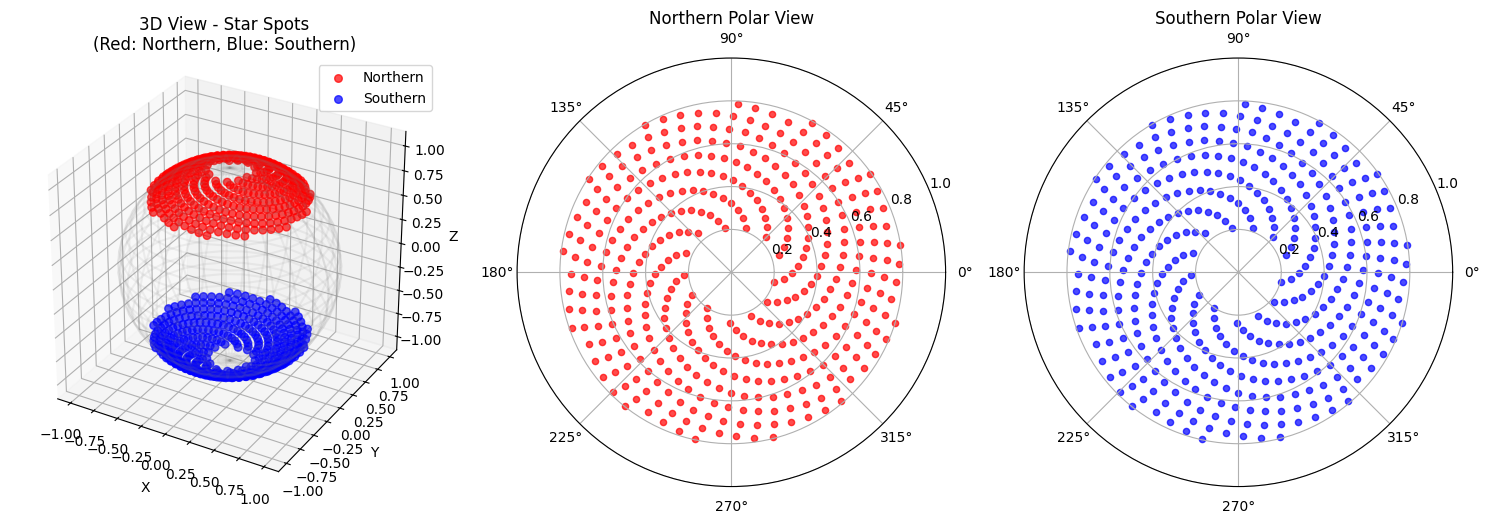

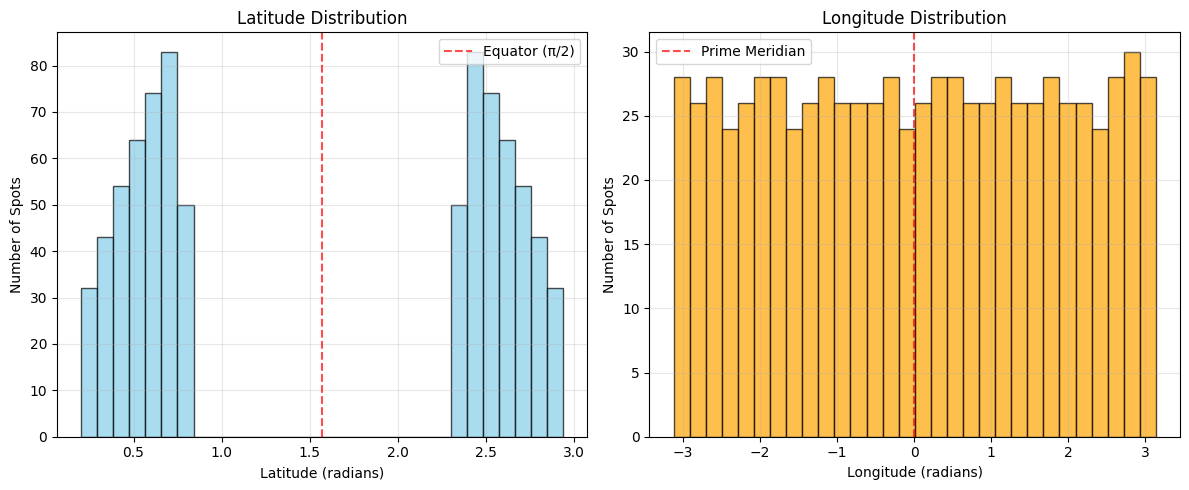



Read the file back and verify data
Data read from file:
Number of spots: 800
Latitude range: 0.201775 to 2.939818 rad
Longitude range: -3.122791 to 3.134851 rad

Verification (original vs read):
Latitudes match: True
Longitudes match: True


In [11]:
# # Usage Example
print("Latitudinal Bands")
n_spots = 400
latitudes, longitudes = direct_polar_spots(
    N=n_spots, 
    min_lat=0.2, 
    max_lat=0.8,
    southern_hemisphere=True
)

# Write to file with metadata
metadata = {
    'Generation Method': 'Latitudinal Band Distribution',
    'Spots per Hemisphere': n_spots,
    'Min Latitude from Pole': '0.3 rad',
    'Max Latitude from Pole': '0.8 rad',
    'Both Hemispheres': 'True'
}

write_spots_to_file(latitudes, longitudes, 'star_spots_radians.txt', metadata=metadata)

print_statistics(latitudes, longitudes)
plot_3d_sphere(latitudes, longitudes)
plot_distributions(latitudes,longitudes)
print("\n" + "="*70 + "\n")

print("Read the file back and verify data")
latitudes_read, longitudes_read, file_metadata = read_spots_from_file('star_spots_radians.txt')

print("Data read from file:")
print(f"Number of spots: {len(latitudes_read)}")
print(f"Latitude range: {latitudes_read.min():.6f} to {latitudes_read.max():.6f} rad")
print(f"Longitude range: {longitudes_read.min():.6f} to {longitudes_read.max():.6f} rad")

print("\nVerification (original vs read):")
print(f"Latitudes match: {np.allclose(latitudes, latitudes_read)}")
print(f"Longitudes match: {np.allclose(longitudes, longitudes_read)}")

In [9]:
print("Read the file back and verify data")
latitudes_read, longitudes_read, file_metadata = read_spots_from_file('star_spots_radians.txt')

print("Data read from file:")
print(f"Number of spots: {len(latitudes_read)}")
print(f"Latitude range: {latitudes_read.min():.6f} to {latitudes_read.max():.6f} rad")
print(f"Longitude range: {longitudes_read.min():.6f} to {longitudes_read.max():.6f} rad")

print("\nVerification (original vs read):")
print(f"Latitudes match: {np.allclose(latitudes, latitudes_read)}")
print(f"Longitudes match: {np.allclose(longitudes, longitudes_read)}")

Read the file back and verify data
Data read from file:
Number of spots: 800
Latitude range: 0.201775 to 2.939818 rad
Longitude range: -3.122791 to 3.134851 rad

Verification (original vs read):
Latitudes match: True
Longitudes match: True
